In [16]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import os

In [3]:
def load_image(image_path):
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

def visualize_gradcam(img_display, heatmap, pred_class, pred_score, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    ax1.imshow(img_display)
    ax1.set_title(f'Original_Image: {title}', fontsize=14)
    ax1.axis('off')

    heatmap_resized = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img_display, 0.6, heatmap_color, 0.4, 0)
    ax2.imshow(superimposed)
    ax2.set_title(f"Predicted Defect Area for {pred_class}. (Confidence: {pred_score:.2f})", fontsize=14)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

In [4]:
class GradCAM:
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.target_layer.register_forward_hook(self._on_forward)

    def _on_forward(self, module, inputs, output):
        self.activations = output.detach()
        def _on_backward(grad):
            self.gradients = grad.detach()
        output.register_hook(_on_backward)

    def __call__(self, x: torch.Tensor, class_idx: int | None = None):
        self.model.zero_grad(set_to_none=True)
        output = self.model(x)
        if class_idx is None:
            class_idx = int(output.argmax(dim=1).item())

        score = output[:, class_idx].sum()
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=False)
        cam = cam.relu()[0]

        cam -= cam.min()
        cam /= cam.max().clamp_min(1e-8)

        return cam.detach().cpu().numpy(), class_idx

In [21]:
def compute_gradcam(img_path, model, transform, device, class_mapping):
    try:
        img = load_image(img_path)
        img_display = np.array(img.resize((224, 224)))
        img_tensor = transform(img).unsqueeze(0).to(device)

        output = model(img_tensor)
        pred_class_idx = torch.argmax(output, dim=1).item()
        pred_score = torch.softmax(output, dim=1)[0, pred_class_idx].item()
        pred_class_name = class_mapping[pred_class_idx]

        grad_cam = GradCAM(model, model.layer4[-1].conv3)
        heatmap, _ = grad_cam(img_tensor, pred_class_idx)

        return img_display, heatmap, pred_class_name, pred_score
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None, None, "Error", 0

In [7]:
idx_to_label = {
    0: 'Crazing',
    1: 'Inclusion',
    2: 'Patches',
    3: 'Pitted',
    4: 'Rolled',
    5: 'Scratches'
}

In [8]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224,244)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

In [9]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {device}')

Using: cuda


In [33]:
checkpoint = torch.load('metal_surface_defect_detector.pth', map_location=device)

model = tv_models.resnet50(weights=tv_models.ResNet50_Weights.IMAGENET1K_V1)
in_features = model.fc.in_features
num_classes = 6

class CustomResNet50Classifier(nn.Module):
    def __init__(self, in_features, num_classes):
        super(CustomResNet50Classifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        out = self.classifier(x)
        return out

model.fc = CustomResNet50Classifier(in_features, num_classes)
model.load_state_dict(checkpoint['model_state_dict'])

model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

Processing Sc_100...


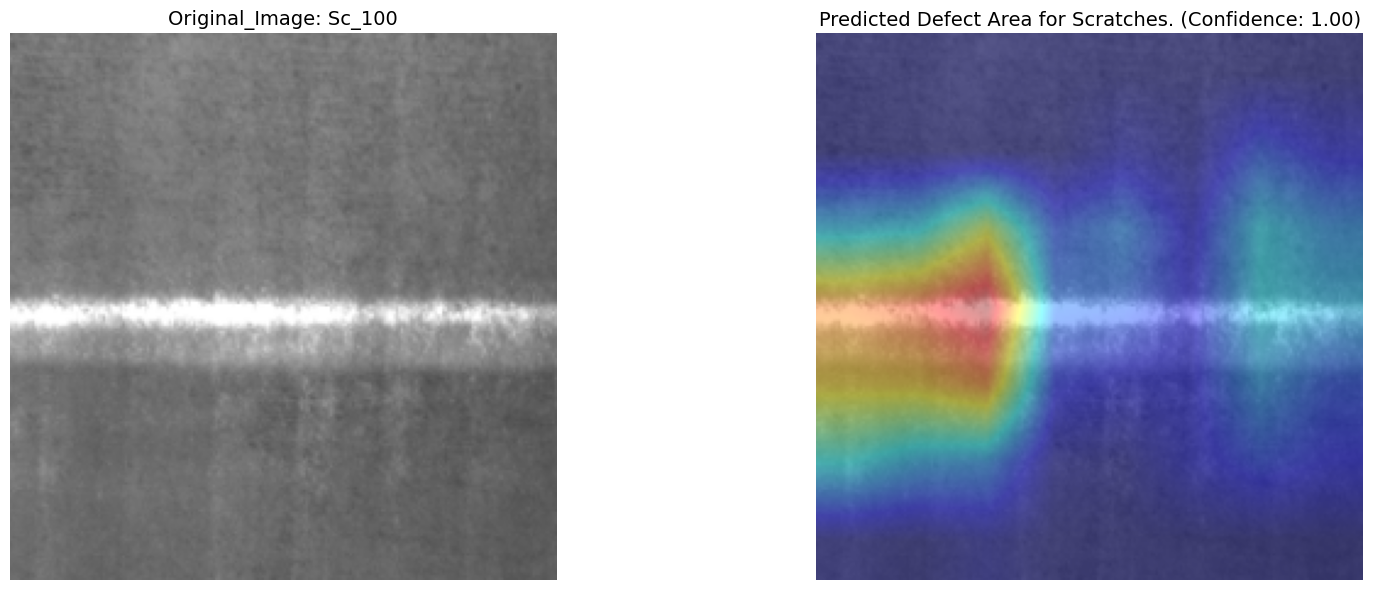

In [37]:
image_files = ['dataset/test/Scratches/Sc_100.bmp']
existing_files = [f for f in image_files if os.path.exists(f)]

for img_path in image_files:
    title = os.path.splitext(os.path.basename(img_path))[0]
    print(f"Processing {title}...")

    img_display, heatmap, pred_class, pred_score = compute_gradcam(
        img_path, model, transform, device, idx_to_label
    )
    if img_display is not None:
        visualize_gradcam(img_display, heatmap, pred_class, pred_score, title)
    else:
        print(f"Skipping visualization for {img_path}")